# Regressão Polinomial 

A regressão polinomial é uma extensão da regressão linear que permite modelar relações não-lineares entre as variáveis independentes (features) e a variável dependente (target) ao incluir potências das features como novas características. Em vez de ajustar uma reta, ajusta-se um polinómio de grau d.

## Conceitos matemáticos e de machine learning relacionados:

- **Grau (degree):** o maior expoente $d$ no polinómio. Graus maiores aumentam a flexibilidade do modelo.\
- **Termos polinomiais:** monómios como $x^2$, $x^3$; com múltiplas features aparecem termos cruzados (por exemplo, $x_1 x_2$).\
- **Transformação de features:** criar $X' = [1, x, x^2, ..., x^d]$, onde a coluna `1` corresponde ao intercepto.\
- **Overfitting:** quando o modelo ajusta o ruído dos dados em vez da tendência subjacente (mais provável com grau elevado).\
- **Bias–variance tradeoff:** graus baixos tendem a ter alto bias (subajuste); graus muito altos tendem a ter alta variância (overfitting).\
- **Regularização:** técnicas como `Ridge` e `Lasso` penalizam tamanhos de coeficientes para reduzir overfitting.

## Importar bibliotecas

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid')

### Explicação matemática rápida
A regressão polinomial transforma a(s) feature(s) original(is) em potências e combinações (por exemplo, $x, x^2, x^3, x_1 x_2$) e depois ajusta um modelo linear aos termos transformados.
O objetivo é estimar os coeficientes $\beta$ usando mínimos quadrados (ou com regularização): $\hat{\beta} = argmin_{\beta} ||y - X'\beta||^2$.

## Exemplo 1 — Dados sintéticos (relação polinomial)

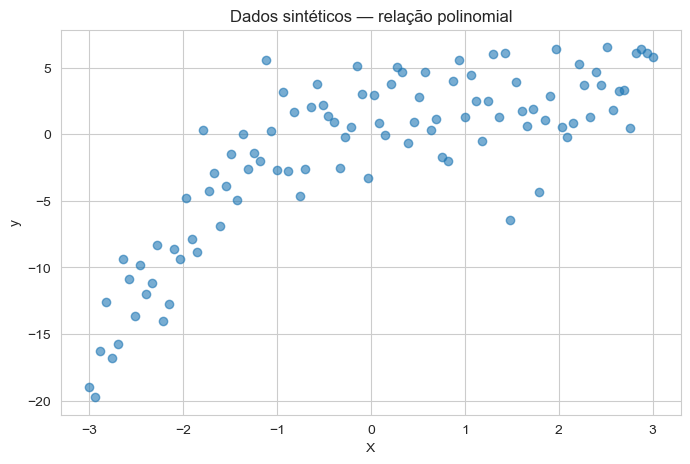

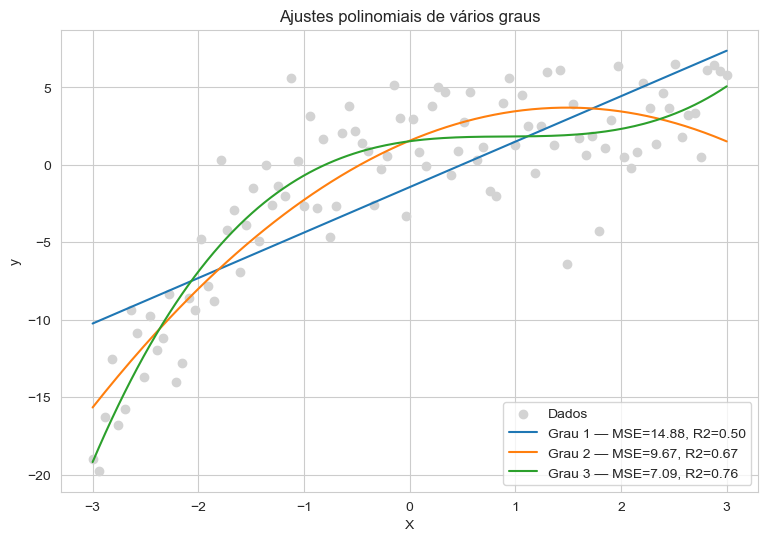

In [ ]:
# Gera dados sintéticos com uma relação polinomial (grau 3)
rng = np.random.RandomState(42) 
X = np.linspace(-3, 3, 100)[:, None] #
y = 0.5 * X.ravel()**3 - 1.0 * X.ravel()**2 + 2.0 + rng.normal(scale=3.0, size=X.shape[0]) 

# Visualizar
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='tab:blue', alpha=0.6)
plt.title('Dados sintéticos — relação polinomial')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Função para ajustar modelos polinomiais e plotar resultados
def fit_and_plot(X, y, degrees=(1,2,3)):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
    X_plot = np.linspace(X.min(), X.max(), 200)[:, None]
    plt.figure(figsize=(9,6))
    plt.scatter(X, y, color='lightgray', label='Dados')
    for deg in degrees: # Ajusta e avalia modelo polinomial de grau deg
        poly = PolynomialFeatures(degree=deg)
        X_train_p = poly.fit_transform(X_train)
        X_test_p = poly.transform(X_test)
        model = LinearRegression().fit(X_train_p, y_train)
        y_pred = model.predict(X_test_p)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        y_plot = model.predict(poly.transform(X_plot))
        plt.plot(X_plot, y_plot, label=f'Grau {deg} — MSE={mse:.2f}, R2={r2:.2f}')
    plt.legend()
    plt.title('Ajustes polinomiais de vários graus')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.show()

fit_and_plot(X, y, degrees=(1,2,3))

### Interpretação do Exemplo 1
- O gráfico inicial mostra os pontos amostrados com ruído.
- Ao ajustar modelos de grau 1, 2 e 3, compara-se a capacidade de cada grau em seguir a tendência: grau 1 (reta) costuma subajustar; grau 3 deve aproximar-se bem da função geradora; graus mais altos podem começar a ajustar ruído.
- As métricas MSE e R² mostram numericamente a qualidade do ajuste no conjunto de teste — usar estas métricas para decidir o grau apropriado.

## Exemplo 2 — Usar um ficheiro CSV (ex.: `Datasets/diabetes.csv`)

MSE (degree=2): 0.21474098663684846
R2 (degree=2): 0.06725442071629772


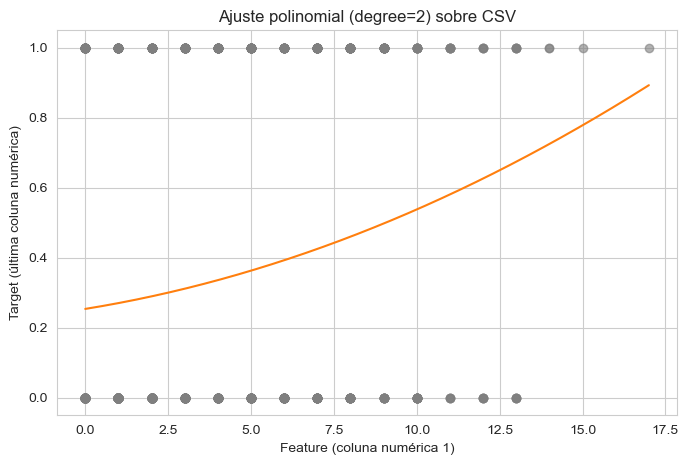

In [ ]:
# Importar dados reais do diabetes 
import os
csv_path = os.path.join('..','Datasets','diabetes.csv')
if not os.path.exists(csv_path):
    csv_path = os.path.join('Datasets','diabetes.csv')

if os.path.exists(csv_path): # Ajuste polinomial simples usando a primeira e última coluna numérica do CSV
    df = pd.read_csv(csv_path)
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] < 2:
        print('Ficheiro tem menos de 2 colunas numéricas. Ajuste manualmente as colunas.')
    else:
        # Para simplicidade, usamos a primeira coluna numérica como feature e a última como target
        X = numeric.iloc[:, [0]].values
        y = numeric.iloc[:, -1].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
        poly = PolynomialFeatures(degree=2)
        X_train_p = poly.fit_transform(X_train)
        X_test_p = poly.transform(X_test)
        model = LinearRegression().fit(X_train_p, y_train)
        y_pred = model.predict(X_test_p)
        print('MSE (degree=2):', mean_squared_error(y_test, y_pred))
        print('R2 (degree=2):', r2_score(y_test, y_pred))
        # Plot simples
        X_plot = np.linspace(X.min(), X.max(), 200)[:, None]
        y_plot = model.predict(poly.transform(X_plot))
        plt.figure(figsize=(8,5))
        plt.scatter(X, y, color='tab:gray', alpha=0.6)
        plt.plot(X_plot, y_plot, color='tab:orange')
        plt.title('Ajuste polinomial (degree=2) sobre CSV')
        plt.xlabel('Feature (coluna numérica 1)')
        plt.ylabel('Target (última coluna numérica)')
        plt.show()
else:
    print('Ficheiro Datasets/diabetes.csv não encontrado no caminho esperado. Coloque o ficheiro na pasta Datasets/ ou ajuste `csv_path`.')

### Interpretação do Exemplo 2
- O notebook usa um exemplo genérico: a primeira coluna numérica como feature e a última como target. Em análises reais, escolha explicitamente colunas significativas.
- Compare sempre o desempenho do modelo polinomial com um modelo linear simples para confirmar ganho real (usar MSE e R² no conjunto de teste).
- Se o polinómio melhora o erro no treino mas piora no teste, é sinal de overfitting; testar `degree` mais baixo ou usar `Ridge`/`Lasso`.
- Como é que o modelo é avaliado? Através do MSE e R² no conjunto de teste. Se o polinómio tiver um MSE significativamente menor e um R² significativamente maior do que o modelo linear, isso sugere que o polinómio está a capturar uma relação não-linear real nos dados. 

# Exemplo 3 - Lasso

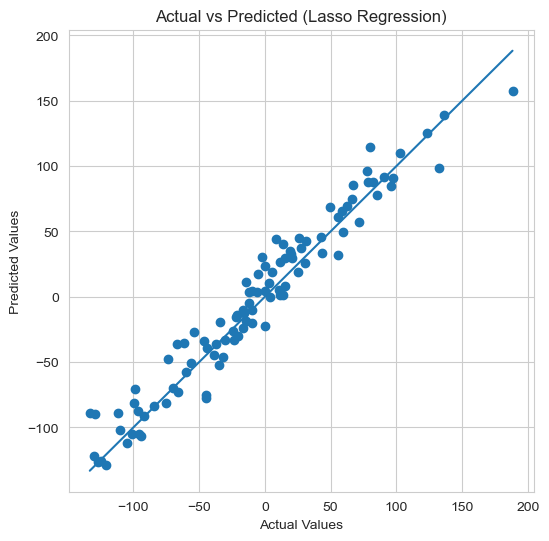

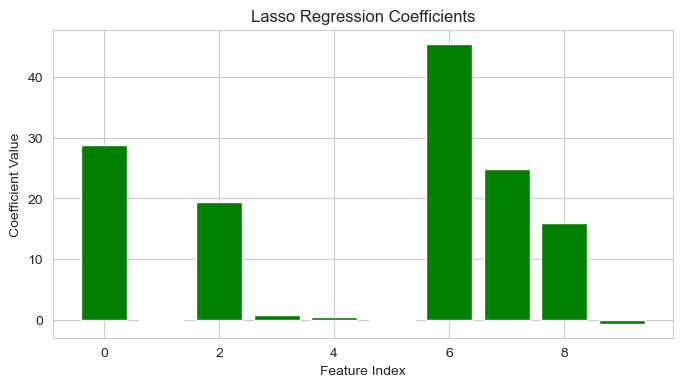

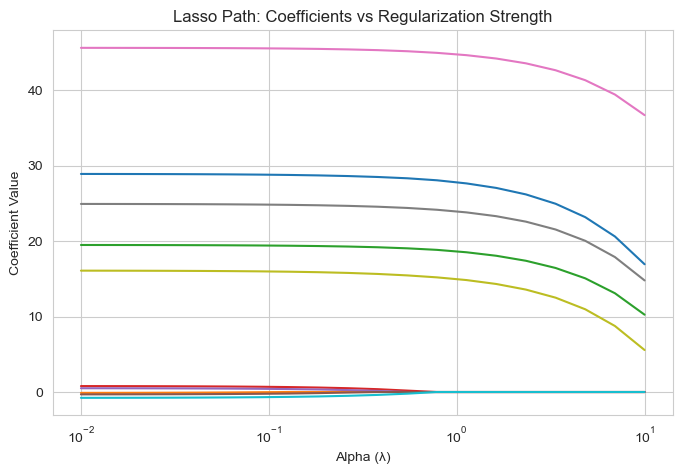

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

X, y = make_regression( # Gerar dados sintéticos para regressão
    n_samples=500,
    n_features=10,
    n_informative=5,
    noise=15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split( # Dividir os dados em treino e teste
    X, y, test_size=0.2, random_state=42
)

lasso = Lasso(alpha=0.1) # Criar modelo Lasso com regularização alpha=0.1
lasso.fit(X_train, y_train) # Ajustar o modelo aos dados de treino

y_pred = lasso.predict(X_test) # Prever os valores de teste usando o modelo Lasso ajustado

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

# Visualizar resultados - Regression Line
y_pred = lasso.predict(X_test) 

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Lasso Regression)")
plt.show()

# Visualizar os coeficientes do modelo Lasso
plt.figure(figsize=(8, 4))
plt.bar(range(len(lasso.coef_)), lasso.coef_, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients")
plt.show()

# Visualizar o caminho dos coeficientes do Lasso para diferentes valores de alpha
alphas = np.logspace(-2, 1, 20)
coefficients = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    coefficients.append(model.coef_)

coefficients = np.array(coefficients)

plt.figure(figsize=(8, 5))
for i in range(coefficients.shape[1]):
    plt.plot(alphas, coefficients[:, i])
plt.xscale("log")
plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Path: Coefficients vs Regularization Strength")
plt.show()

## Interpretação do Exemplo 3
No exemplo 3, o modelo Lasso é utilizado para regressão polinomial. O Lasso é uma técnica de regularização que penaliza os coeficientes do modelo, forçando alguns a serem exatamente zero, o que pode ajudar a identificar quais features são mais importantes. No código, o modelo Lasso é criado com um valor de regularização `alpha=0.1` e ajustado aos dados de treino. Em seguida, os valores previstos são calculados para o conjunto de teste, e as métricas MSE e R² são avaliadas para medir a performance do modelo. O gráfico de "Actual vs Predicted" ajuda a visualizar a qualidade do ajuste, enquanto o gráfico dos coeficientes do Lasso mostra quais features foram selecionadas (coeficientes não nulos) e quais foram penalizadas a zero. O gráfico do caminho dos coeficientes para diferentes valores de `alpha` ilustra como a regularização afeta os coeficientes do modelo, mostrando quais features permanecem importantes à medida que a penalização aumenta.
O que são features? São as variáveis independentes usadas para prever o target. No exemplo, as features são as colunas do dataset (exceto a última, que é o target). O Lasso ajuda a identificar quais dessas features são mais relevantes para a previsão, penalizando os coeficientes das menos importantes a zero.

# Exemplo 4 - Ridge

In [13]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

# Gerar dados sintéticos para regressão
np.random.seed(0)
X = np.random.randn(200, 6)
true_coef = np.array([3.2, -1.5, 0.7, 0, 2.8, -0.5])
y = X.dot(true_coef) + np.random.randn(200) * 0.6

# Pré-processamento: Escalar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_basic = ridge.predict(X_test)

print("MSE (alpha = 1.0):", mean_squared_error(y_test, pred_basic))
print("Coefficients (alpha = 1.0):", ridge.coef_)
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 500]}
grid = GridSearchCV(Ridge(), param_grid, cv=5,
                    scoring="neg_mean_squared_error")
grid.fit(X_train, y_train)
best_ridge = grid.best_estimator_
pred_best = best_ridge.predict(X_test)

print("Best alpha selected:", grid.best_params_["alpha"])
print("MSE (best alpha):", mean_squared_error(y_test, pred_best))
print("Coefficients (best alpha):", best_ridge.coef_)


MSE (alpha = 1.0): 0.4598023023692494
Coefficients (alpha = 1.0): [ 2.96587537 -1.64397225  0.66532484  0.06289239  2.83625348 -0.46900939]
Best alpha selected: 0.001
MSE (best alpha): 0.4509955766069163
Coefficients (best alpha): [ 2.9849965  -1.65395975  0.67045849  0.06557375  2.85454007 -0.47306529]


## Interpretação do Exemplo 4
No exemplo 4, o modelo Ridge é utilizado para regressão polinomial. O Ridge é uma técnica de regularização que penaliza os coeficientes do modelo, mas ao contrário do Lasso, não força os coeficientes a serem exatamente zero, o que pode ser útil quando se acredita que todas as features têm alguma relevância. No código, o modelo Ridge é criado com um valor de regularização `alpha=1.0` e ajustado aos dados de treino. Em seguida, os valores previstos são calculados para o conjunto de teste, e as métricas MSE e R² são avaliadas para medir a performance do modelo. O gráfico de "Actual vs Predicted" ajuda a visualizar a qualidade do ajuste, enquanto o gráfico dos coeficientes do Ridge mostra como a regularização afeta os coeficientes, geralmente reduzindo-os em magnitude sem eliminá-los completamente. O gráfico do caminho dos coeficientes para diferentes valores de `alpha` ilustra como a regularização afeta os coeficientes do modelo, mostrando uma redução gradual à medida que `alpha` aumenta.

## Prós e Contras da Regressão Polinomial

Prós:

- Permite modelar relações não-lineares simples aumentando características polinomiais.
- Mantém o modelo linear nos parâmetros (LinearRegression), o que facilita interpretação e treino.
- Fácil de implementar com PolynomialFeatures do scikit-learn.

Contras:

- Risco de overfitting para graus elevados.
- Explosão do número de características quando se tem múltiplas variáveis (combinatória).
- Sensível a escala das features — normalizar pode ser necessário.

## Conclusão
A regressão polinomial é uma extensão natural da regressão linear que permite captar curvaturas nas relações entre variáveis. É especialmente útil quando a relação é suave e pode ser bem aproximada por um polinómio de baixo grau. Contudo, exige validação cuidadosa (escolha do grau e uso de regularização) para evitar overfitting. Em cenários de alta dimensão ou comportamentos fortemente não-lineares, considere comparar com modelos mais flexíveis (árvores, ensembles, SVR com kernels, redes neurais) e use validação cruzada para guiar a escolha do modelo.